In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             recall_score, precision_score, f1_score, 
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Data loaded: {df.shape}")
print(f"Fraud cases: {df['is_fraud'].sum()}")

Data loaded: (339607, 15)
Fraud cases: 1782


In [2]:
df['trans_datetime'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_datetime'].dt.hour
df['day_of_week'] = df['trans_datetime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
df['dob_datetime'] = pd.to_datetime(df['dob'])
df['age'] = df['trans_datetime'].dt.year - df['dob_datetime'].dt.year
df['amt_log'] = np.log1p(df['amt'])

le_category = LabelEncoder()
le_state = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])
df['state_encoded'] = le_state.fit_transform(df['state'])

features = ['amt', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'age', 
            'amt_log', 'category_encoded', 'state_encoded']

X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data ready!")
print(f"Training set: {len(X_train):,}")
print(f"Test set: {len(X_test):,}")

Data ready!
Training set: 271,685
Test set: 67,922


In [3]:
print("Training Decision Tree")

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

dt_recall = recall_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:, 1])

print(f"Decision Tree trained!")
print(f"Recall:    {dt_recall:.4f} ({dt_recall*100:.1f}%)")
print(f"Precision: {dt_precision:.4f} ({dt_precision*100:.1f}%)")
print(f"F1-Score:  {dt_f1:.4f}")
print(f"ROC-AUC:   {dt_auc:.4f}")

Training Decision Tree
Decision Tree trained!
Recall:    0.9129 (91.3%)
Precision: 0.2057 (20.6%)
F1-Score:  0.3357
ROC-AUC:   0.9566


In [4]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

rf_recall = recall_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1])

print(f"Random Forest trained!")
print(f"Recall:    {rf_recall:.4f} ({rf_recall*100:.1f}%)")
print(f"Precision: {rf_precision:.4f} ({rf_precision*100:.1f}%)")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print(f"\nRecall change vs Decision Tree: {dt_recall*100:.1f}% → {rf_recall*100:.1f}%")
print(f"Precision change: {dt_precision*100:.1f}% → {rf_precision*100:.1f}%")

Random Forest trained!
Recall:    0.8876 (88.8%)
Precision: 0.3607 (36.1%)
F1-Score:  0.5130
ROC-AUC:   0.9892

Recall change vs Decision Tree: 91.3% → 88.8%
Precision change: 20.6% → 36.1%


In [5]:
# XGBoost

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale:.1f}")

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    scale_pos_weight=scale,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:, 1])

print(f"XGBoost trained!")
print(f"Recall:    {xgb_recall:.4f} ({xgb_recall*100:.1f}%)")
print(f"Precision: {xgb_precision:.4f} ({xgb_precision*100:.1f}%)")
print(f"F1-Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_auc:.4f}")

print(f"\nRecall change vs Decision Tree: {dt_recall*100:.1f}% → {xgb_recall*100:.1f}%")
print(f"Precision change: {dt_precision*100:.1f}% → {xgb_precision*100:.1f}%")

Scale pos weight: 189.5
XGBoost trained!
Recall:    0.8961 (89.6%)
Precision: 0.5444 (54.4%)
F1-Score:  0.6773
ROC-AUC:   0.9969

Recall change vs Decision Tree: 91.3% → 89.6%
Precision change: 20.6% → 54.4%


FINAL MODEL COMPARISON
        Model   Recall  Precision       F1  ROC-AUC
Decision Tree 0.912921   0.205696 0.335744 0.956568
Random Forest 0.887640   0.360731 0.512987 0.989174
      XGBoost 0.896067   0.544369 0.677282 0.996947


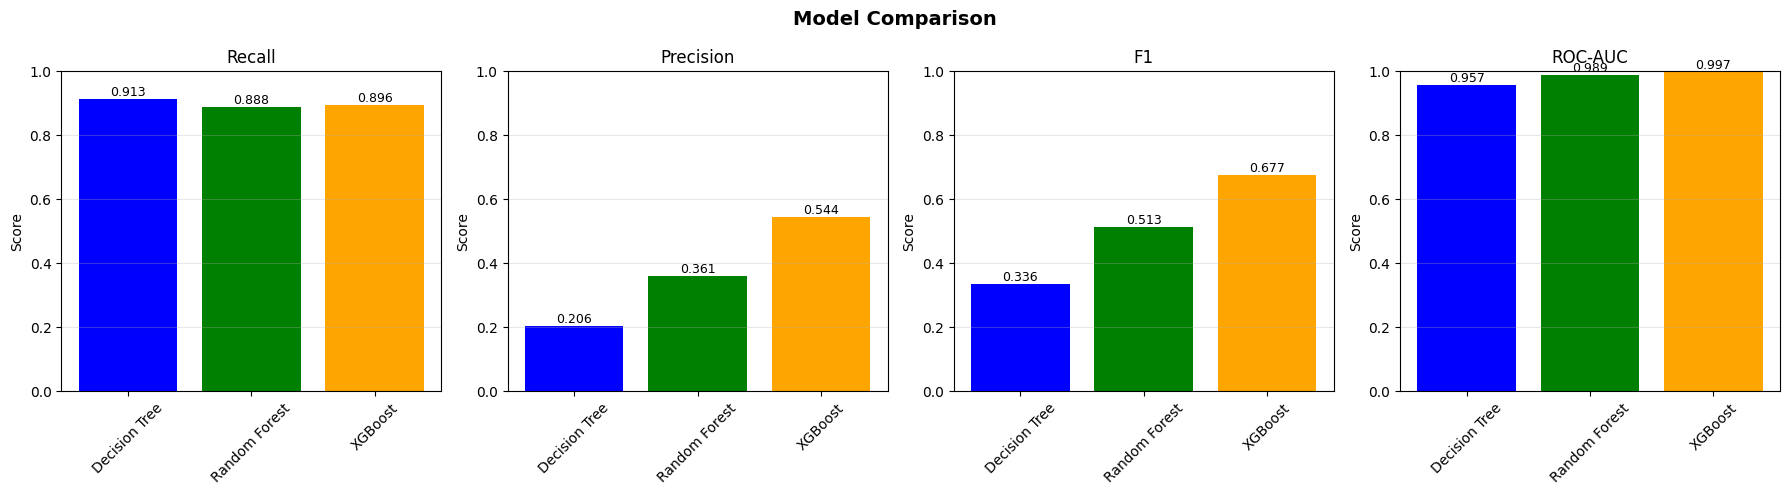

In [6]:
print("FINAL MODEL COMPARISON")
print("=" * 60)

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Recall': [dt_recall, rf_recall, xgb_recall],
    'Precision': [dt_precision, rf_precision, xgb_precision],
    'F1': [dt_f1, rf_f1, xgb_f1],
    'ROC-AUC': [dt_auc, rf_auc, xgb_auc]
})

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = ['Recall', 'Precision', 'F1', 'ROC-AUC']
colors = ['blue', 'green', 'orange']

for idx, metric in enumerate(metrics):
    axes[idx].bar(results['Model'], results[metric], color=colors)
    axes[idx].set_title(f'{metric}')
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(results[metric]):
        axes[idx].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

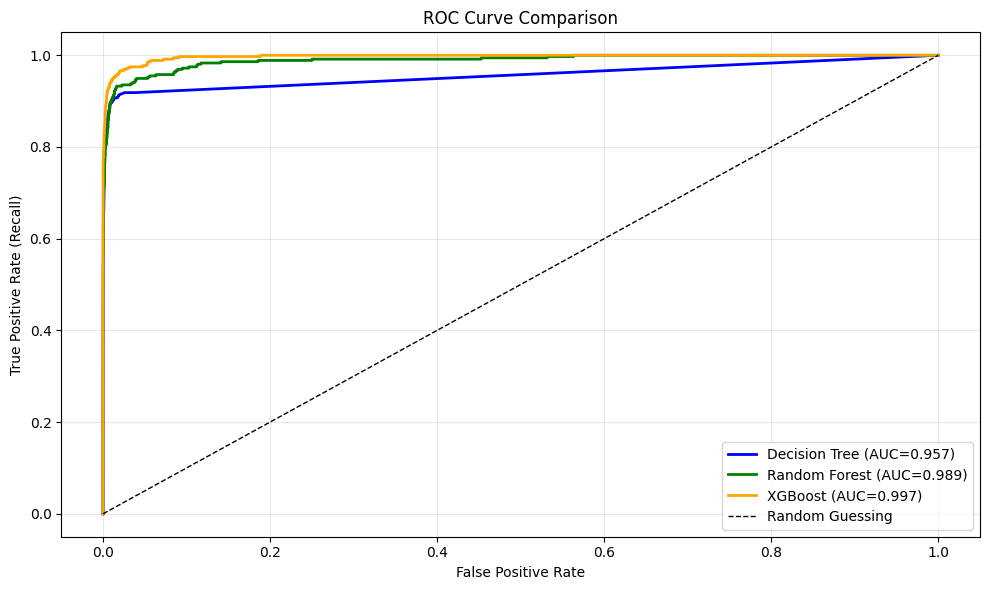

In [7]:
# ROC Curves for all models
plt.figure(figsize=(10, 6))

models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

colors = ['blue', 'green', 'orange']

for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

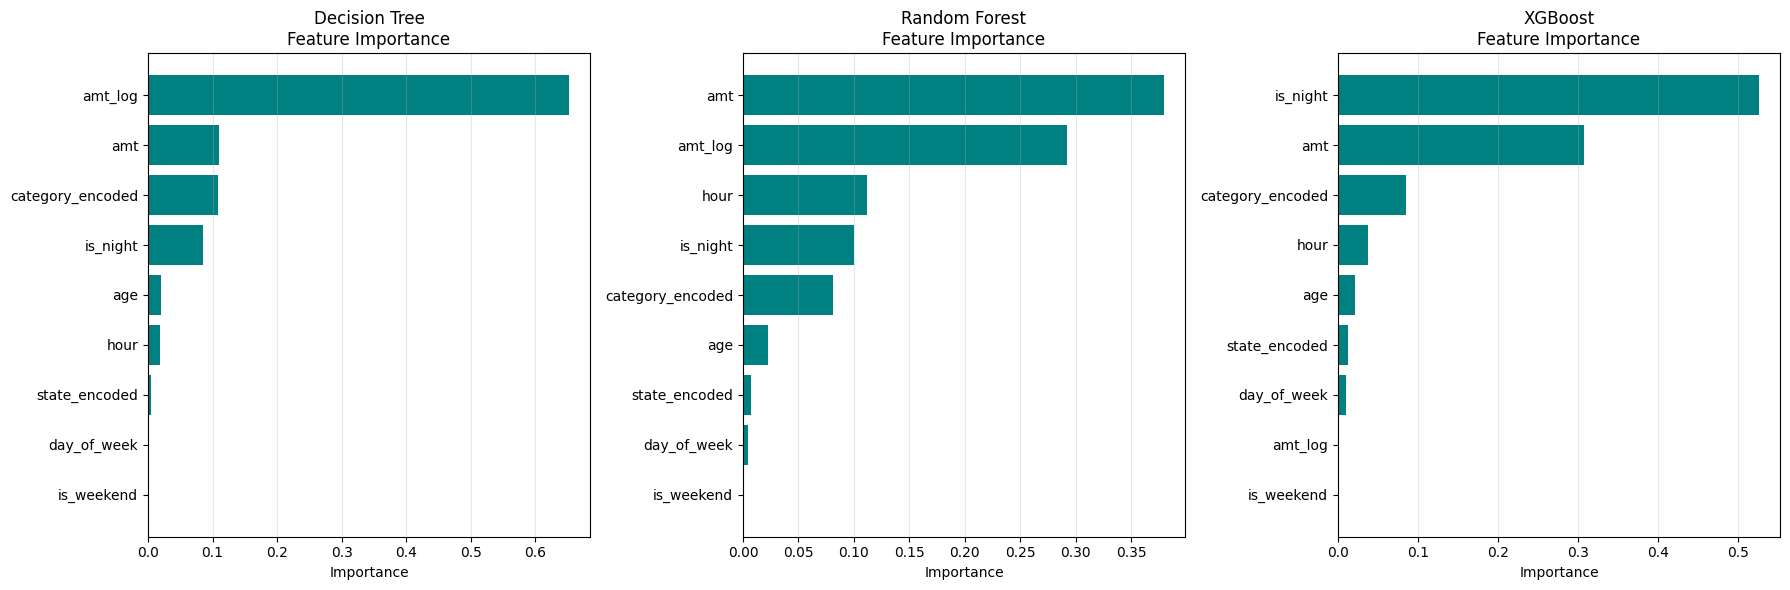

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_importance = {
    'Decision Tree': dt.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb.feature_importances_
}

for idx, (name, importance) in enumerate(models_importance.items()):
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': importance
    }).sort_values('Importance', ascending=True)
    
    axes[idx].barh(feat_imp['Feature'], feat_imp['Importance'], color='teal')
    axes[idx].set_title(f'{name}\nFeature Importance')
    axes[idx].set_xlabel('Importance')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
results.to_csv('../results/metrics/model_comparison.csv', index=False)

print("=" * 60)
print(f"""
WINNER: XGBoost
""")


WINNER: XGBoost

